# Title
# Impact of Data Quality on Anomaly Detection in Business Process Logs

# Objective:
# - Analyze how degradation affects anomaly detection performance
# - Compare detectors under different data quality issues
# - Identify robustness patterns

In [29]:
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def load_results(path_pattern):
    files = glob.glob(path_pattern)
    return [json.load(open(f)) for f in files]

baseline_results = load_results("../results/baseline/*.json")
degradation_results = load_results("../results/degradation/*.json")

print(f"Loaded {len(baseline_results)} baseline runs")
print(f"Loaded {len(degradation_results)} degradation runs")

Loaded 5 baseline runs
Loaded 60 degradation runs


In [31]:
def build_dataframe(results):
    rows = []

    for r in results:
        config = r.get("config") or {}

        dimension = config.get("dimension", "baseline")
        level = config.get("level", 0.0)
        seed = config.get("seed", None)

        for detector, metrics in r["overall_metrics"].items():
            rows.append({
                "dimension": dimension,
                "level": level,
                "seed": seed,
                "detector": detector,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
            })

    return pd.DataFrame(rows)


df_base = build_dataframe(baseline_results)
df_deg = build_dataframe(degradation_results)

# Baseline expanded as 0% degradation for every degradation dimension
dimensions = df_deg["dimension"].unique()

baseline_expanded = []

for dim in dimensions:
    temp = df_base.copy()
    temp["dimension"] = dim
    temp["level"] = 0.0
    baseline_expanded.append(temp)

df_plot = pd.concat([df_deg] + baseline_expanded, ignore_index=True)

df_plot.head()

,dimension,level,seed,detector,precision,recall,f1
0,accuracy,0.1,42,knn,0.892256,0.736111,0.806697
1,accuracy,0.1,42,lof,0.527066,0.513889,0.520394
2,accuracy,0.1,42,iforest,0.776515,0.569444,0.657051
3,accuracy,0.1,42,dbscan,0.827381,0.772222,0.798851
4,accuracy,0.1,43,knn,0.870861,0.730556,0.794562


In [32]:
agg_plot = df_plot.groupby(
    ["dimension", "level", "detector"]
).agg(
    precision_mean=("precision", "mean"),
    precision_std=("precision", "std"),
    recall_mean=("recall", "mean"),
    recall_std=("recall", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
).reset_index()

agg_plot.head()

,dimension,level,detector,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,accuracy,0.0,dbscan,0.828874,0.021537,0.780000,0.038560,0.802914,0.014423
1,accuracy,0.0,iforest,0.722495,0.032841,0.581111,0.040702,0.643493,0.030806
2,accuracy,0.0,knn,0.885242,0.015557,0.729444,0.026687,0.799449,0.013537
3,accuracy,0.0,lof,0.528396,0.027591,0.465556,0.036935,0.494482,0.029362
4,accuracy,0.1,dbscan,0.826931,0.023694,0.782222,0.036250,0.803205,0.013670


In [33]:
baseline = df_base.groupby(
    ["detector"]
).agg(
    precision_mean=("precision", "mean"),
    precision_std=("precision", "std"),
    recall_mean=("recall", "mean"),
    recall_std=("recall", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
).reset_index()

display(baseline)

,detector,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,dbscan,0.828874,0.021537,0.780000,0.038560,0.802914,0.014423
1,iforest,0.722495,0.032841,0.581111,0.040702,0.643493,0.030806
2,knn,0.885242,0.015557,0.729444,0.026687,0.799449,0.013537
3,lof,0.528396,0.027591,0.465556,0.036935,0.494482,0.029362


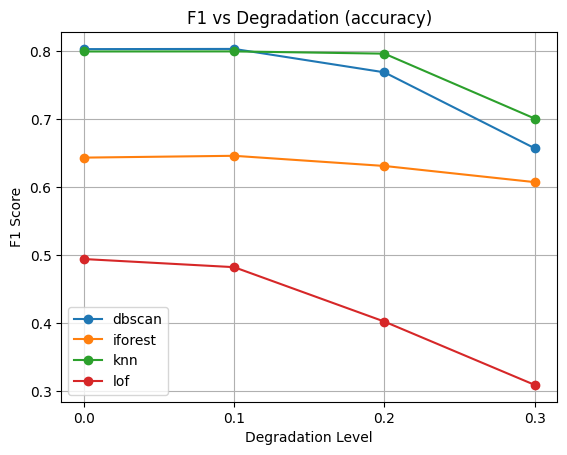

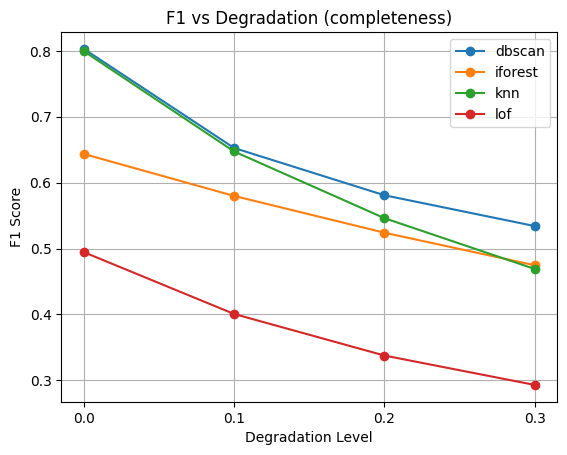

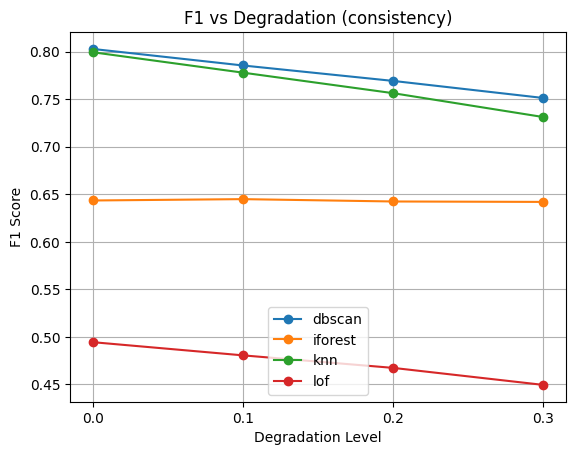

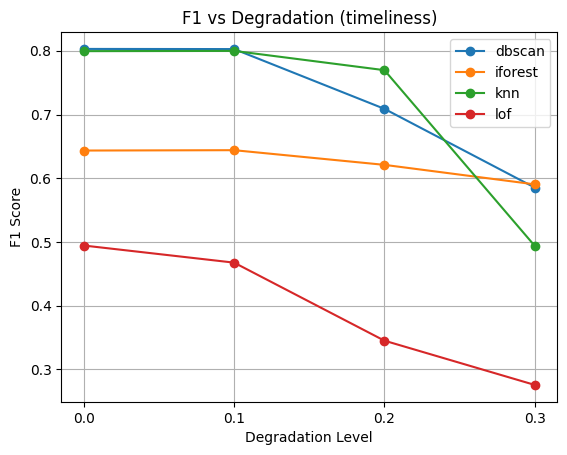

In [34]:
for dim in df_deg["dimension"].unique():
    subset = agg_plot[agg_plot["dimension"] == dim]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector].sort_values("level")

        plt.plot(
            d["level"],
            d["f1_mean"],
            marker="o",
            label=detector
        )

    plt.title(f"F1 vs Degradation ({dim})")
    plt.xlabel("Degradation Level")
    plt.ylabel("F1 Score")
    plt.xticks([0.0, 0.1, 0.2, 0.3])
    plt.legend()
    plt.grid()
    plt.show()

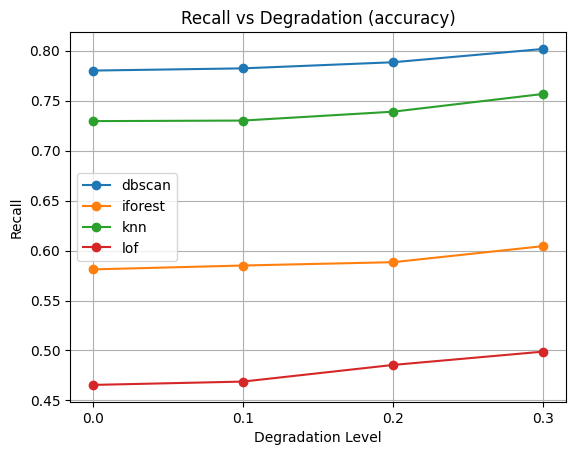

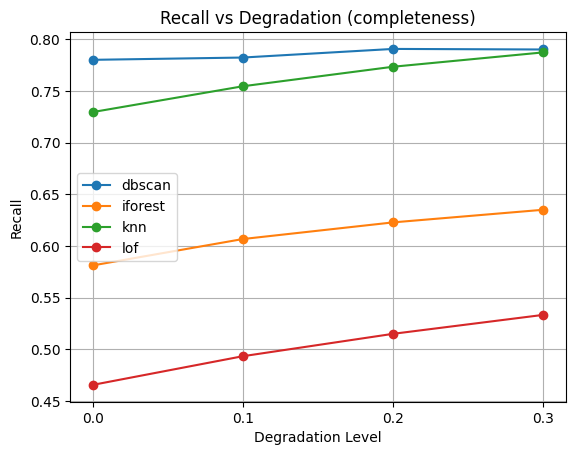

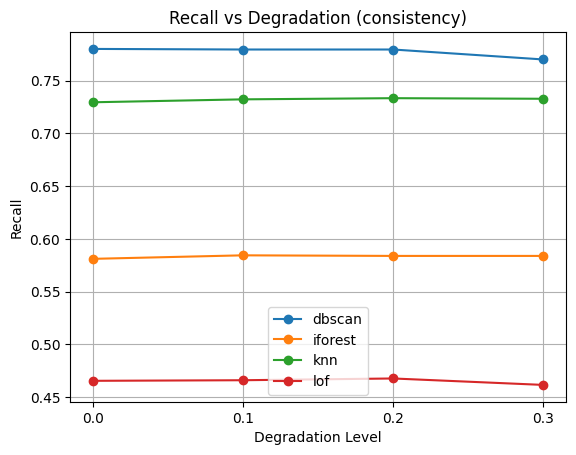

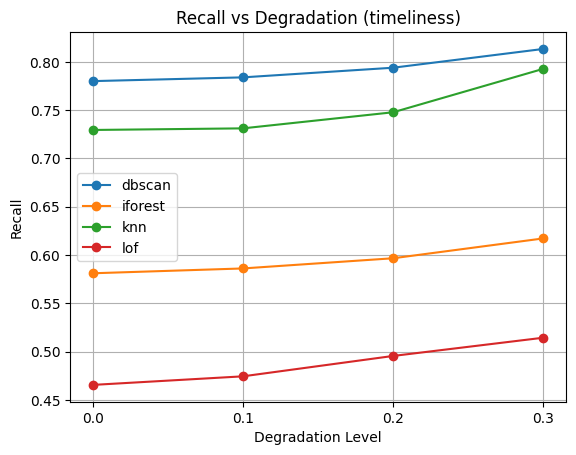

In [35]:
for dim in df_deg["dimension"].unique():
    subset = agg_plot[agg_plot["dimension"] == dim]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector].sort_values("level")

        plt.plot(
            d["level"],
            d["recall_mean"],
            marker="o",
            label=detector
        )

    plt.title(f"Recall vs Degradation ({dim})")
    plt.xlabel("Degradation Level")
    plt.ylabel("Recall")
    plt.xticks([0.0, 0.1, 0.2, 0.3])
    plt.legend()
    plt.grid()
    plt.show()
    plt.show()

In [36]:
baseline_f1 = baseline.set_index("detector")["f1_mean"]

delta_rows = []

for _, row in agg_plot.iterrows():
    detector = row["detector"]
    base = baseline_f1[detector]

    delta_rows.append({
        "dimension": row["dimension"],
        "level": row["level"],
        "detector": detector,
        "delta_f1": row["f1_mean"] - base,
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.head()

,dimension,level,detector,delta_f1
0,accuracy,0.0,dbscan,0.000000
1,accuracy,0.0,iforest,0.000000
2,accuracy,0.0,knn,0.000000
3,accuracy,0.0,lof,0.000000
4,accuracy,0.1,dbscan,0.000291


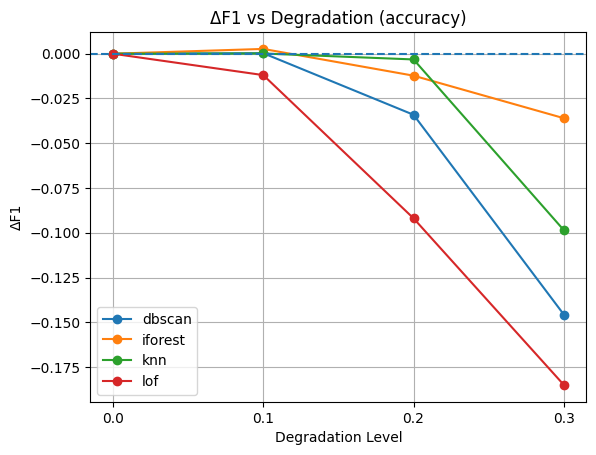

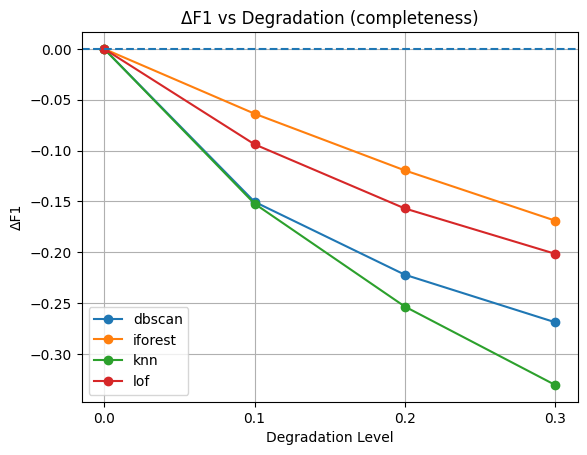

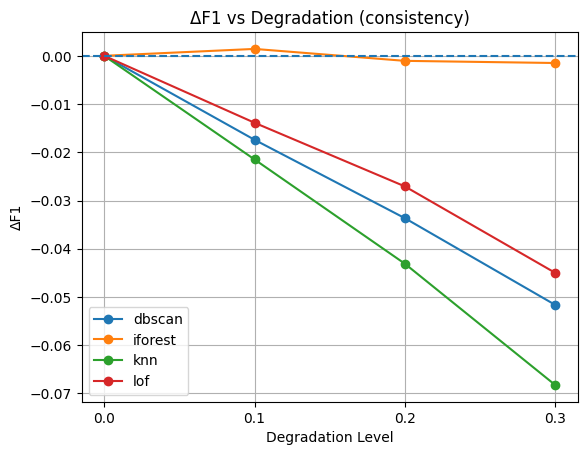

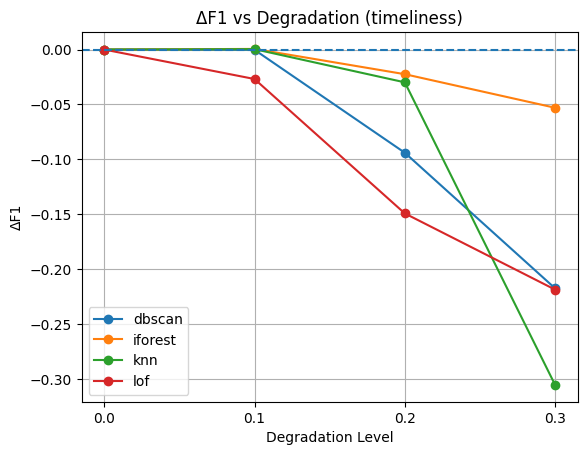

In [37]:
for dim in delta_df["dimension"].unique():
    subset = delta_df[delta_df["dimension"] == dim]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector].sort_values("level")

        plt.plot(
            d["level"],
            d["delta_f1"],
            marker="o",
            label=detector
        )

    plt.axhline(0, linestyle="--")
    plt.title(f"ΔF1 vs Degradation ({dim})")
    plt.xlabel("Degradation Level")
    plt.ylabel("ΔF1")
    plt.xticks([0.0, 0.1, 0.2, 0.3])
    plt.legend()
    plt.grid()
    plt.show()

In [40]:
def build_subtype_df(degradation_results, baseline_results):
    rows = []

    # 🔹 Degradation results
    for r in degradation_results:
        config = r["config"]

        for detector, subtypes in r["per_subtype_metrics"].items():
            for subtype, metrics in subtypes.items():
                rows.append({
                    "dimension": config["dimension"],
                    "level": config["level"],
                    "seed": config["seed"],
                    "detector": detector,
                    "subtype": subtype,
                    "recall": metrics["recall"]
                })

    # 🔹 Baseline (level = 0 για όλα τα dimensions)
    dimensions = list(set(r["config"]["dimension"] for r in degradation_results))

    for r in baseline_results:
        seed = r["config"]["seed"]

        for detector, subtypes in r["per_subtype_metrics"].items():
            for subtype, metrics in subtypes.items():

                for dim in dimensions:
                    rows.append({
                        "dimension": dim,
                        "level": 0.0,
                        "seed": seed,
                        "detector": detector,
                        "subtype": subtype,
                        "recall": metrics["recall"]
                    })

    return pd.DataFrame(rows)

subtype_df = build_subtype_df(degradation_results, baseline_results)
subtype_df.head()

,dimension,level,seed,detector,subtype,recall
0,accuracy,0.1,42,knn,contextual_out_of_range,1.000000
1,accuracy,0.1,42,knn,contextual_priority_duration,1.000000
2,accuracy,0.1,42,knn,contextual_wrong_resource,0.530612
3,accuracy,0.1,42,knn,structural_double_end,0.409091
4,accuracy,0.1,42,knn,structural_missing_and_wrong,1.000000


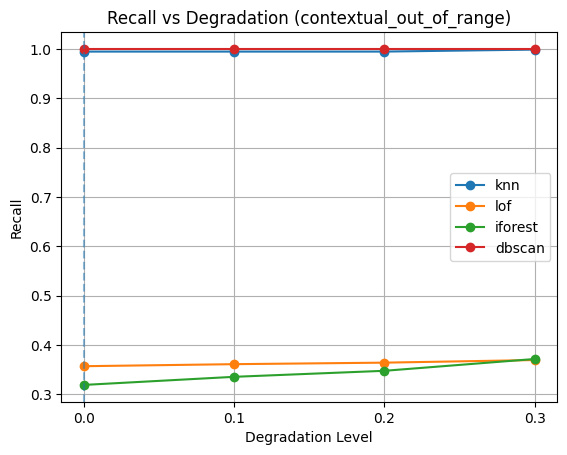

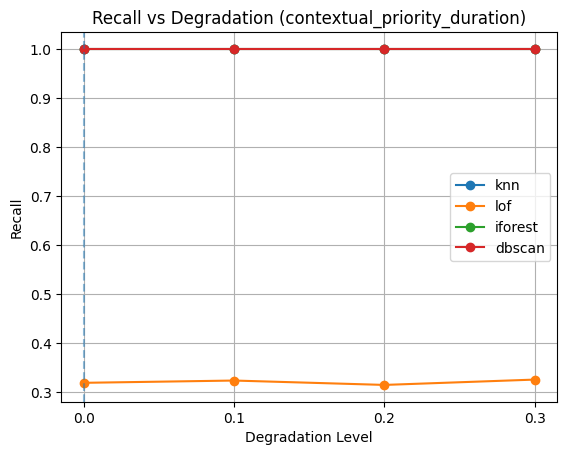

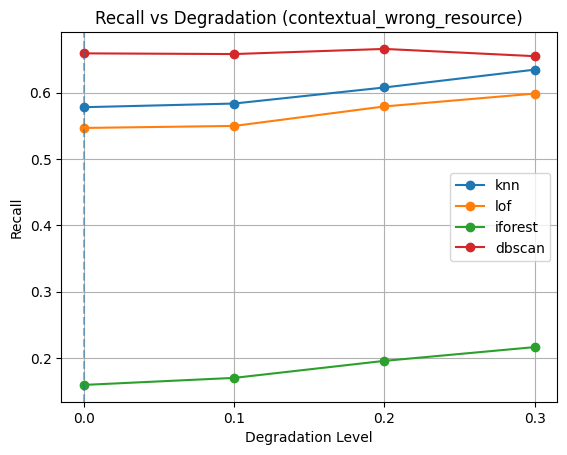

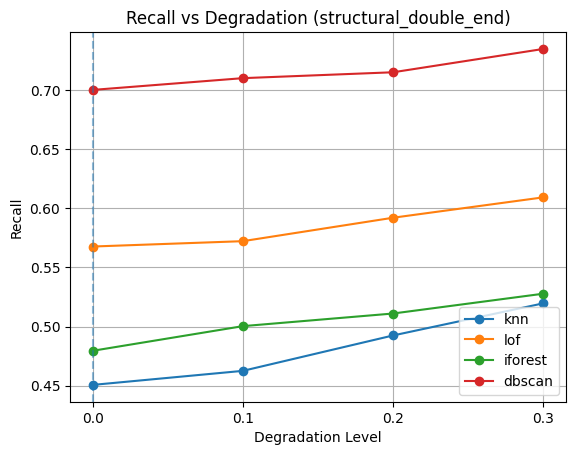

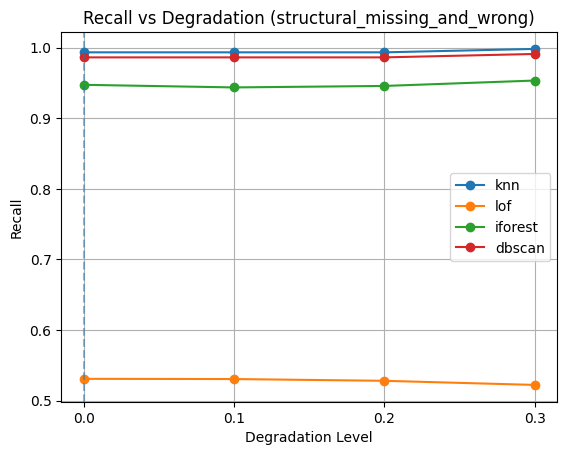

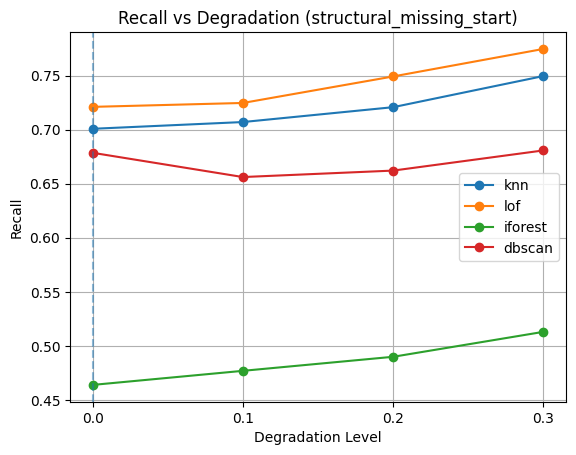

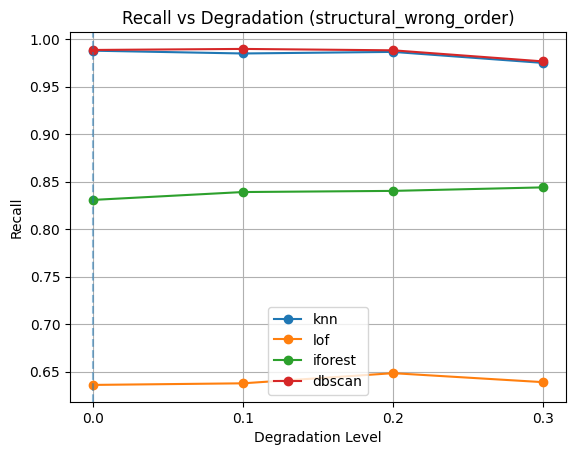

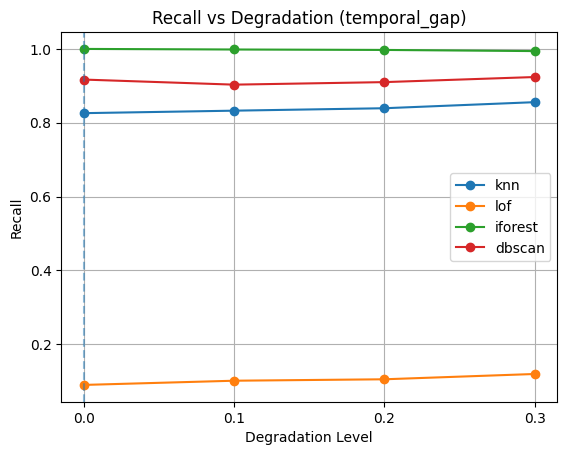

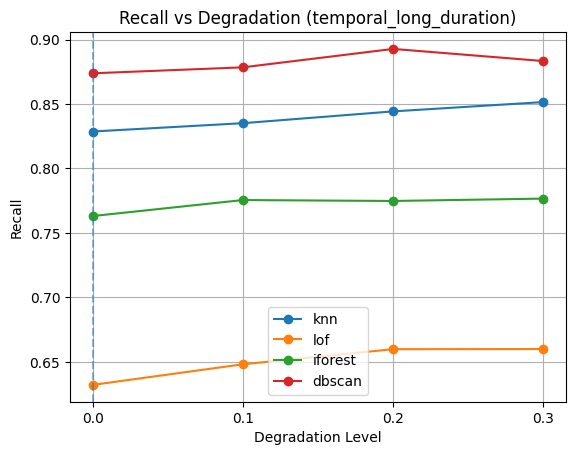

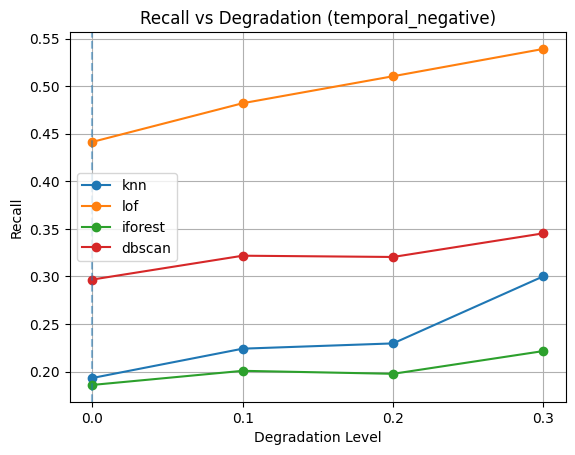

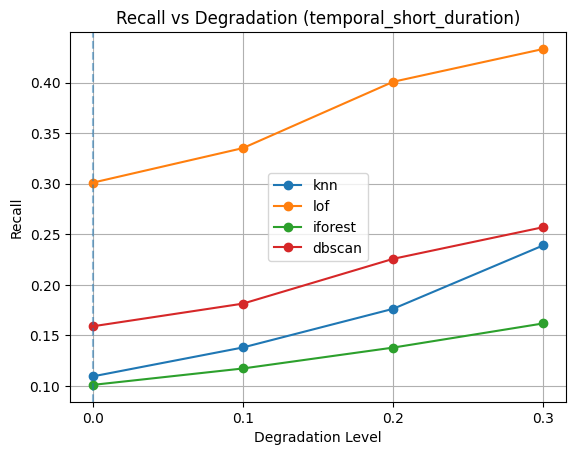

In [41]:
for subtype in subtype_df["subtype"].unique():
    subset = subtype_df[subtype_df["subtype"] == subtype]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector]

        grouped = (
            d.groupby("level")["recall"]
            .mean()
            .reset_index()
            .sort_values("level")
        )

        plt.plot(
            grouped["level"],
            grouped["recall"],
            marker="o",
            label=detector
        )

    plt.title(f"Recall vs Degradation ({subtype})")
    plt.xlabel("Degradation Level")
    plt.ylabel("Recall")

    # 🔥 σημαντικό: include 0%
    plt.xticks([0.0, 0.1, 0.2, 0.3])

    # 🔥 προαιρετικό: baseline highlight
    plt.axvline(0.0, linestyle="--", alpha=0.5)

    plt.legend()
    plt.grid()
    plt.show()